In [4]:
# INSTALL DEPENDENCIES
import math
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import math

from dash import Dash, dcc, html, Input, Output
import plotly.express as px

Total slices: 149
Stride: 5
Valid slices: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45] ...


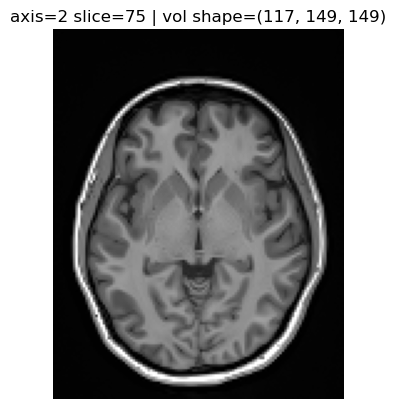

In [3]:
# DISPLAY IMAGE USING PYTHON
PATH = "/Users/cassidyschuman/Downloads/Classes/Senior Spring/Clinical Preceptorship/example_ouptut/xprx/sub-hc02jbw_ses-1_task-rest_acq-multiecho_t1_ds.nii.gz" 

img = nib.load(PATH)
vol = img.get_fdata().astype(np.float32)

# If 4D (timeseries), pick first volume
if vol.ndim == 4:
    vol = vol[..., 0]

vol = np.nan_to_num(vol)

def get_slice(vol, axis, idx):
    if axis == 0:      # sagittal
        sl = vol[idx, :, :]
    elif axis == 1:    # coronal
        sl = vol[:, idx, :]
    else:              # axial
        sl = vol[:, :, idx]
    return np.rot90(sl)

axis = 2
stride = 5  # every 5th slice
max_idx = vol.shape[axis] - 1

valid_slices = list(range(0, max_idx + 1, stride))

print("Total slices:", max_idx + 1)
print("Stride:", stride)
print("Valid slices:", valid_slices[:10], "...")

idx = valid_slices[len(valid_slices) // 2]
sl = get_slice(vol, axis, idx)

# Simple contrast: clip to percentiles
lo, hi = np.percentile(sl, (1, 99))
sl_disp = np.clip(sl, lo, hi)

plt.imshow(sl_disp, cmap="gray")
plt.title(f"axis={axis} slice={idx} | vol shape={vol.shape}")
plt.axis("off")
plt.show()

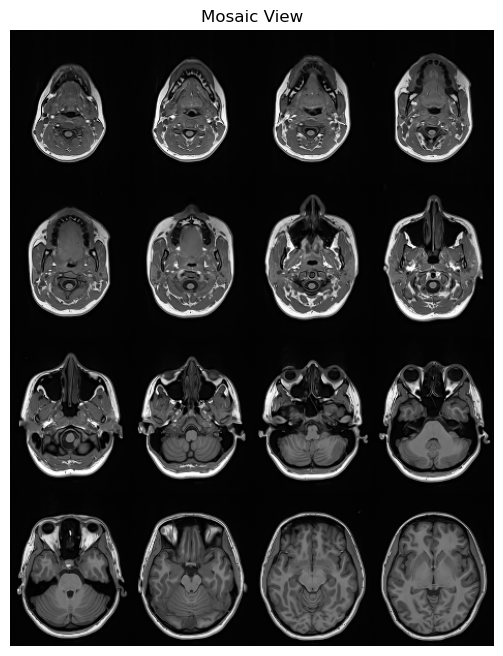

In [5]:
# BUILD MOSAIC

def make_mosaic(vol, axis=2, stride=5, n_slices=16):
    max_idx = vol.shape[axis] - 1
    indices = list(range(0, max_idx + 1, stride))[:n_slices]

    slices = []
    for i in indices:
        sl = get_slice(vol, axis, i)
        lo, hi = np.percentile(sl, (1, 99))
        sl = np.clip(sl, lo, hi)
        slices.append(sl)

    cols = int(math.sqrt(len(slices)))
    rows = int(math.ceil(len(slices) / cols))

    h, w = slices[0].shape
    mosaic = np.zeros((rows*h, cols*w))

    for i, sl in enumerate(slices):
        r = i // cols
        c = i % cols
        mosaic[r*h:(r+1)*h, c*w:(c+1)*w] = sl

    return mosaic

mosaic = make_mosaic(vol, axis=2, stride=5, n_slices=16)

plt.figure(figsize=(8,8))
plt.imshow(mosaic, cmap="gray")
plt.title("Mosaic View")
plt.axis("off")
plt.show()
